In [42]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import csv

import matplotlib.pyplot as plt
from IPython.display import Audio
from scipy.io import wavfile
import scipy
import os
import kagglehub

In [43]:
path = kagglehub.model_download("google/yamnet/tensorFlow2/yamnet")

In [44]:
model = hub.load(path)

In [45]:
# Find the name of the class with the top score when mean-aggregated across frames.
def class_names_from_csv(class_map_csv_text):
  """Returns list of class names corresponding to score vector."""
  class_names = []
  with tf.io.gfile.GFile(class_map_csv_text) as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
      class_names.append(row['display_name'])

  return class_names

class_map_path = model.class_map_path().numpy()
class_names = class_names_from_csv(class_map_path)

In [46]:
def ensure_sample_rate(original_sample_rate, waveform,
                       desired_sample_rate=16000):
  """Resample waveform if required."""
  if original_sample_rate != desired_sample_rate:
    desired_length = int(round(float(len(waveform)) /
                               original_sample_rate * desired_sample_rate))
    waveform = scipy.signal.resample(waveform, desired_length)
  return desired_sample_rate, waveform

In [47]:
import os
import numpy as np
import tensorflow as tf
import scipy.signal
from scipy.io import wavfile

audio_dir = '/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/Videos/ansiedade/'
captured_classes_anxiety = []

files = sorted([f for f in os.listdir(audio_dir) if f.lower().endswith('.wav')])

for fname in files:
    audio_path = os.path.join(audio_dir, fname)
    try:
        sample_rate, waveform = wavfile.read(audio_path)
    except Exception as e:
        print(f"Erro lendo {fname}: {e}")
        continue

    # convert to mono
    if waveform.ndim > 1:
        waveform = np.mean(waveform, axis=1)

    # ensure sample rate
    sample_rate, waveform = ensure_sample_rate(sample_rate, waveform)

    # convert to float32 in [-1, 1]
    if np.issubdtype(waveform.dtype, np.integer):
        waveform = waveform.astype(np.float32) / np.iinfo(np.int16).max
    else:
        waveform = waveform.astype(np.float32)

    waveform = np.nan_to_num(waveform)  # remove NaN/Inf

    # convert to TensorFlow tensor and run model
    waveform_tf = tf.convert_to_tensor(waveform, dtype=tf.float32)
    scores, embeddings, spectrogram = model(waveform_tf)
    scores_np = scores.numpy()
    mean_scores = np.mean(scores_np, axis=0)
    top_class = class_names[mean_scores.argmax()]
    captured_classes_anxiety.append(top_class)
    print(f"{fname} -> {top_class}")

0_DHxAwz6tY3B.wav -> Music
10_DIKWyhqPRdD.wav -> Alarm
11_DHHhFfeJKkk.wav -> Speech
12_CmSdSD8DOWn.wav -> Speech
14_DIhSVH4uEJM.wav -> Speech
15_C122H9QgCkw.wav -> Music
16_DGopD0-OqrE.wav -> Speech
17_C_Y8n0MyQk2.wav -> Speech
18_C22KfCGuHq0.wav -> Speech
19_DB6UVblR3Zk.wav -> Speech
1_DI1qW67OT4b.wav -> Music
20_DB44CefNoDj.wav -> Speech
22_C9smnmiyRmg.wav -> Alarm
23_Cy3Dpd4u2mA.wav -> Speech
24_DHsw8yeO8NO.wav -> Speech
25_DFxKFhURbku.wav -> Speech
26_CvgSgassFg0.wav -> Speech
27_DGDi3npRQIc.wav -> Chant
28_DGNuPILRyat.wav -> Speech
29_C1aWYnIPozR.wav -> Music
2_DHtCgJ7O-KR.wav -> Music
30_DGg2RXdy1j-.wav -> Speech
31_DFn5FpmJe0H.wav -> Music
32_DJEmOkLNtgY.wav -> Speech
33_C-ldne6S5wG.wav -> Speech
34_CwQFok_NiFM.wav -> Speech
35_DHr1-TrA9ym.wav -> Music
36_DFIT9jRO-Hn.wav -> Speech
37_C7X3GcFAqY6.wav -> Music
38_DHuSp8ZvDuk.wav -> Speech
39_DI0BPHdxloo.wav -> Music
3_C9PYPffuoVd.wav -> Speech
40_DH7Z-D3u1-z.wav -> Speech
41_DGAyEIlotw1.wav -> Speech
42_DCAaMEFSyYI.wav -> Music
43

/tmp/ipykernel_4793/1602075347.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=values, y=labels, palette="gray")


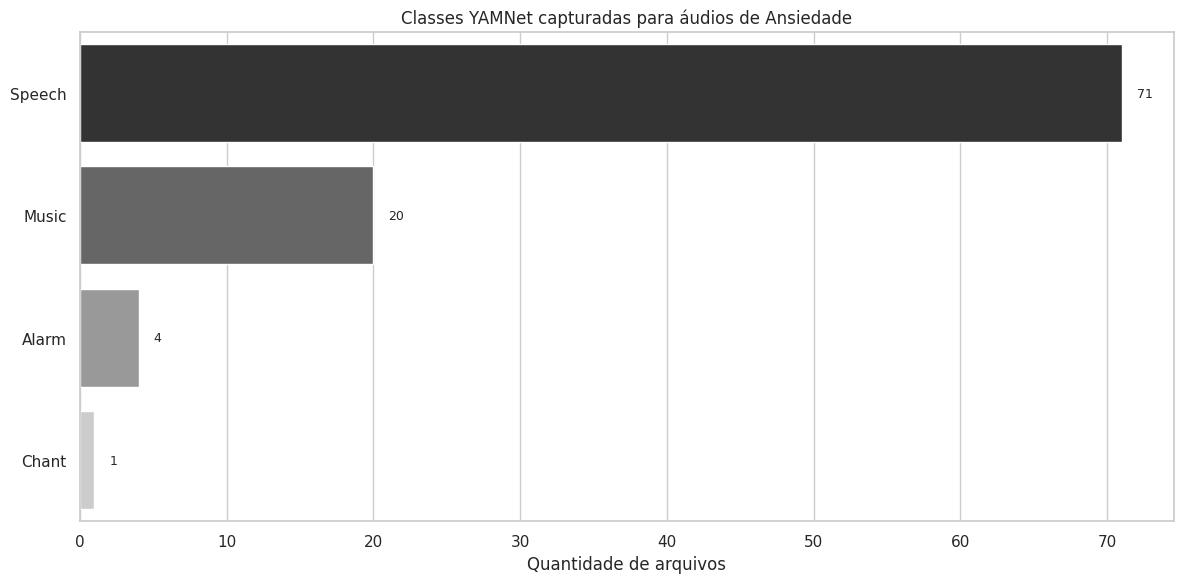

In [48]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

counts = Counter(captured_classes_anxiety)
if not counts:
    print("Nenhuma classe capturada.")
else:
    labels, values = zip(*counts.most_common())
    top_k = 30
    labels = list(labels)[:top_k]
    values = list(values)[:top_k]

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, max(6, 0.35 * len(labels))))
    ax = sns.barplot(x=values, y=labels, palette="gray")
    ax.set_xlabel("Quantidade de arquivos")
    ax.set_ylabel("")
    ax.set_title("Classes YAMNet capturadas para áudios de Ansiedade")

    # Anota valores ao lado das barras
    x_offset = max(1, 0.01 * max(values))
    for i, v in enumerate(values):
        ax.text(v + x_offset, i, str(v), va="center", fontsize=9)

    plt.tight_layout()
    plt.show()
# ...existing code...

/tmp/ipykernel_4793/889555640.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=values, y=labels, palette="gray")


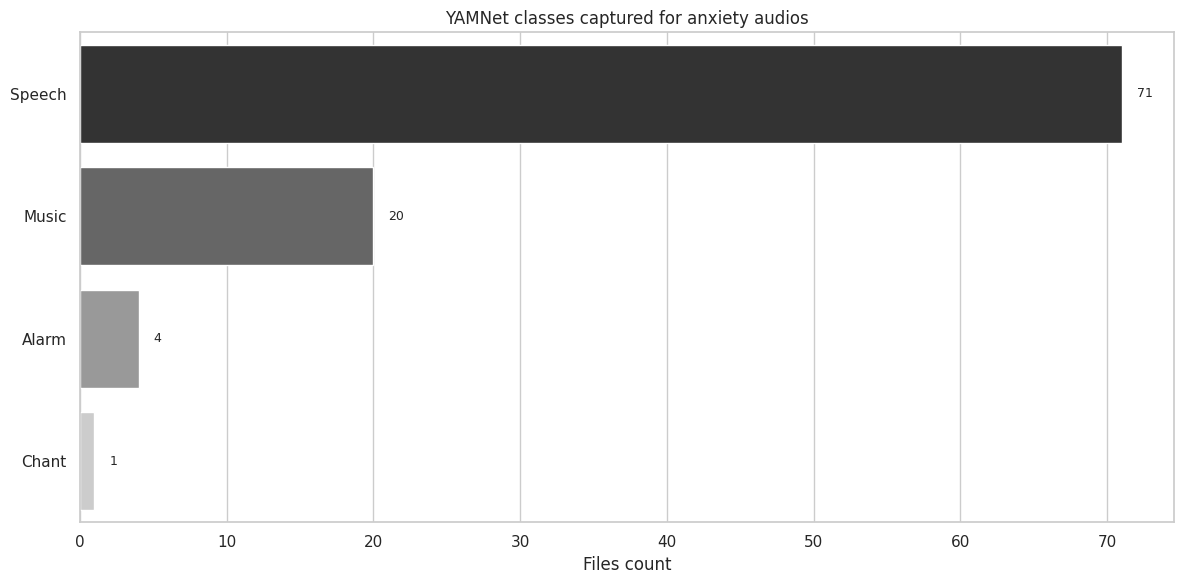

In [49]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

counts = Counter(captured_classes_anxiety)
if not counts:
    print("Nenhuma classe capturada.")
else:
    labels, values = zip(*counts.most_common())
    top_k = 30
    labels = list(labels)[:top_k]
    values = list(values)[:top_k]

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, max(6, 0.35 * len(labels))))
    ax = sns.barplot(x=values, y=labels, palette="gray")
    ax.set_xlabel("Files count")
    ax.set_ylabel("")
    ax.set_title("YAMNet classes captured for anxiety audios")

    # Anota valores ao lado das barras
    x_offset = max(1, 0.01 * max(values))
    for i, v in enumerate(values):
        ax.text(v + x_offset, i, str(v), va="center", fontsize=9)

    plt.tight_layout()
    plt.show()
# ...existing code...

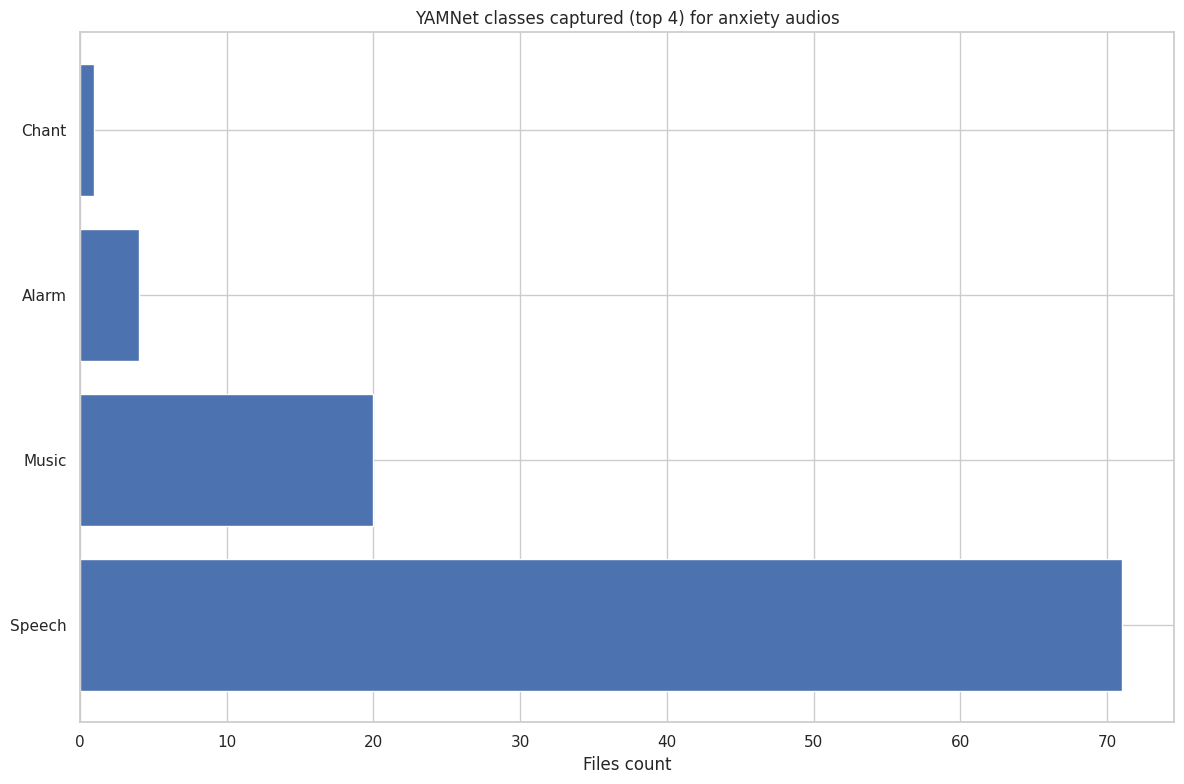

In [50]:
from collections import Counter
import matplotlib.pyplot as plt

counts = Counter(captured_classes_anxiety)
if not counts:
    print("Nenhuma classe capturada.")
else:
    # ordena por frequência decrescente
    labels, values = zip(*counts.most_common())

    plt.figure(figsize=(12, 8))
    plt.barh(range(len(labels))[::-1], values[::-1], color='C0')
    plt.yticks(range(len(labels))[::-1], labels[::-1])
    plt.xlabel("Files count")
    plt.title(f"YAMNet classes captured (top {len(labels)}) for anxiety audios")
  
    plt.tight_layout()
    plt.show()

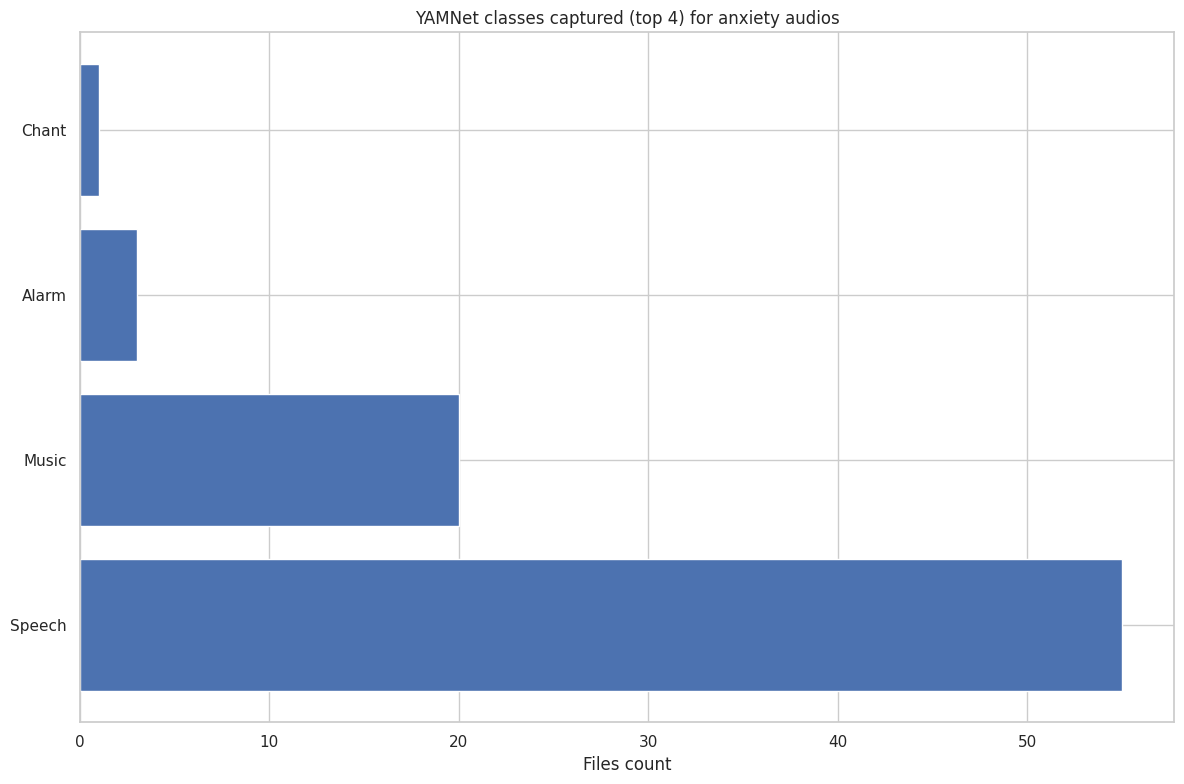

In [51]:
from collections import Counter
import matplotlib.pyplot as plt

counts = Counter(captured_classes)
if not counts:
    print("Nenhuma classe capturada.")
else:
    labels, values = zip(*counts.most_common())

    plt.figure(figsize=(12, 8))
    plt.barh(range(len(labels))[::-1], values[::-1], color='C0')
    plt.yticks(range(len(labels))[::-1], labels[::-1])
    plt.xlabel("Files count")
    plt.title(f"YAMNet classes captured (top {len(labels)}) for anxiety audios")
  
    plt.tight_layout()
    plt.show()

In [52]:
import os
import numpy as np
import tensorflow as tf
import scipy.signal
from scipy.io import wavfile

audio_dir = '/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/Videos/depressao/'
captured_classes_depression = []

files = sorted([f for f in os.listdir(audio_dir) if f.lower().endswith('.wav')])

for fname in files:
    audio_path = os.path.join(audio_dir, fname)
    try:
        sample_rate, waveform = wavfile.read(audio_path)
    except Exception as e:
        print(f"Erro lendo {fname}: {e}")
        continue

    # convert to mono
    if waveform.ndim > 1:
        waveform = np.mean(waveform, axis=1)

    # ensure sample rate
    sample_rate, waveform = ensure_sample_rate(sample_rate, waveform)

    # convert to float32 in [-1, 1]
    if np.issubdtype(waveform.dtype, np.integer):
        waveform = waveform.astype(np.float32) / np.iinfo(np.int16).max
    else:
        waveform = waveform.astype(np.float32)

    waveform = np.nan_to_num(waveform)  # remove NaN/Inf

    # convert to TensorFlow tensor and run model
    waveform_tf = tf.convert_to_tensor(waveform, dtype=tf.float32)
    scores, embeddings, spectrogram = model(waveform_tf)
    scores_np = scores.numpy()
    mean_scores = np.mean(scores_np, axis=0)
    top_class = class_names[mean_scores.argmax()]
    captured_classes_depression.append(top_class)
    print(f"{fname} -> {top_class}")

0_C27vNYcuS5p.wav -> Music
10_C8nzLwqtfpo.wav -> Speech
12_C8fVN7NOD_E.wav -> Speech
13_C7NTxtqM2fZ.wav -> Speech
14_C7vFqIoMvmS.wav -> Chant
15_C9oE9g-N3vF.wav -> Speech
16_C75nQO0OwG2.wav -> Speech
18_C-LquvoSSWr.wav -> Speech
19_C9oadDwsvce.wav -> Music
1_C9PzOaIO0-y.wav -> Speech
20_C7sb1jtpowN.wav -> Speech
22_C7hbuR-OFtO.wav -> Speech
23_C-D7RDhyk_7.wav -> Speech
24_C9NSAm6Azrk.wav -> Music
26_C93WU_2Oiye.wav -> Speech
28_C7h1G-BgPLj.wav -> Speech
29_C7eoxgwpzI6.wav -> Speech
2_C9lewlavm90.wav -> Music
30_C7ndv-BO5g6.wav -> Speech
31_C4QJiEYOlsm.wav -> Speech
32_C-oxO0mOc0v.wav -> Music
35_C7e4aeHRXHV.wav -> Speech
36_C7jrX1DsbV9.wav -> Alarm
37_C9s0NCtBqmN.wav -> Speech
38_C9hXsGTRvS9.wav -> Music
3_C83aEbXNMA2.wav -> Speech
40_C8Sn4lCJuC-.wav -> Speech
43_C-UHJDrO81e.wav -> Speech
44_C9cw7Lxuea_.wav -> Music
45_C8XXbOHxF64.wav -> Speech
46_C49kwP_hsy_.wav -> Speech
48_C-JHKzbSCVe.wav -> Speech
49_C82ci91Jlc1.wav -> Speech
4_C8p3bHYuV69.wav -> Speech
51_C-vqSzSSlUX.wav -> Music


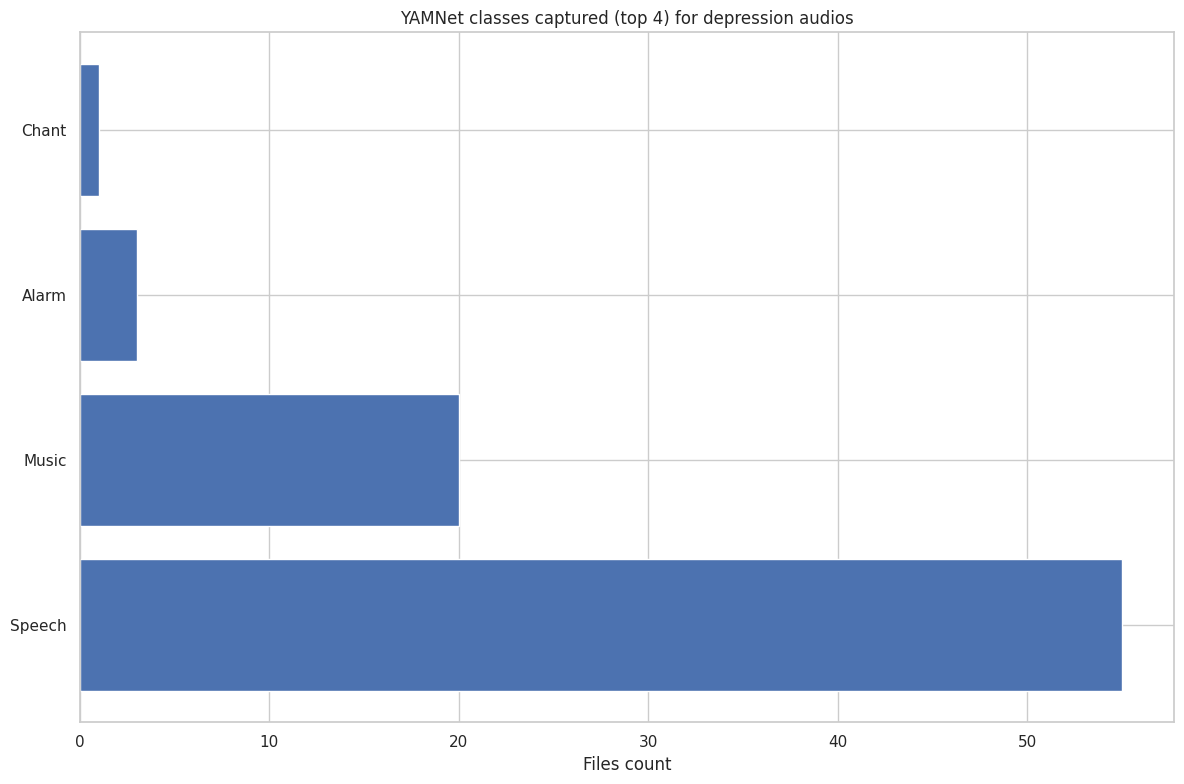

In [53]:
from collections import Counter
import matplotlib.pyplot as plt

counts = Counter(captured_classes_depression)
if not counts:
    print("Nenhuma classe capturada.")
else:
    labels, values = zip(*counts.most_common())

    plt.figure(figsize=(12, 8))
    plt.barh(range(len(labels))[::-1], values[::-1], color='C0')
    plt.yticks(range(len(labels))[::-1], labels[::-1])
    plt.xlabel("Files count")
    plt.title(f"YAMNet classes captured (top {len(labels)}) for depression audios")
  
    plt.tight_layout()
    plt.show()

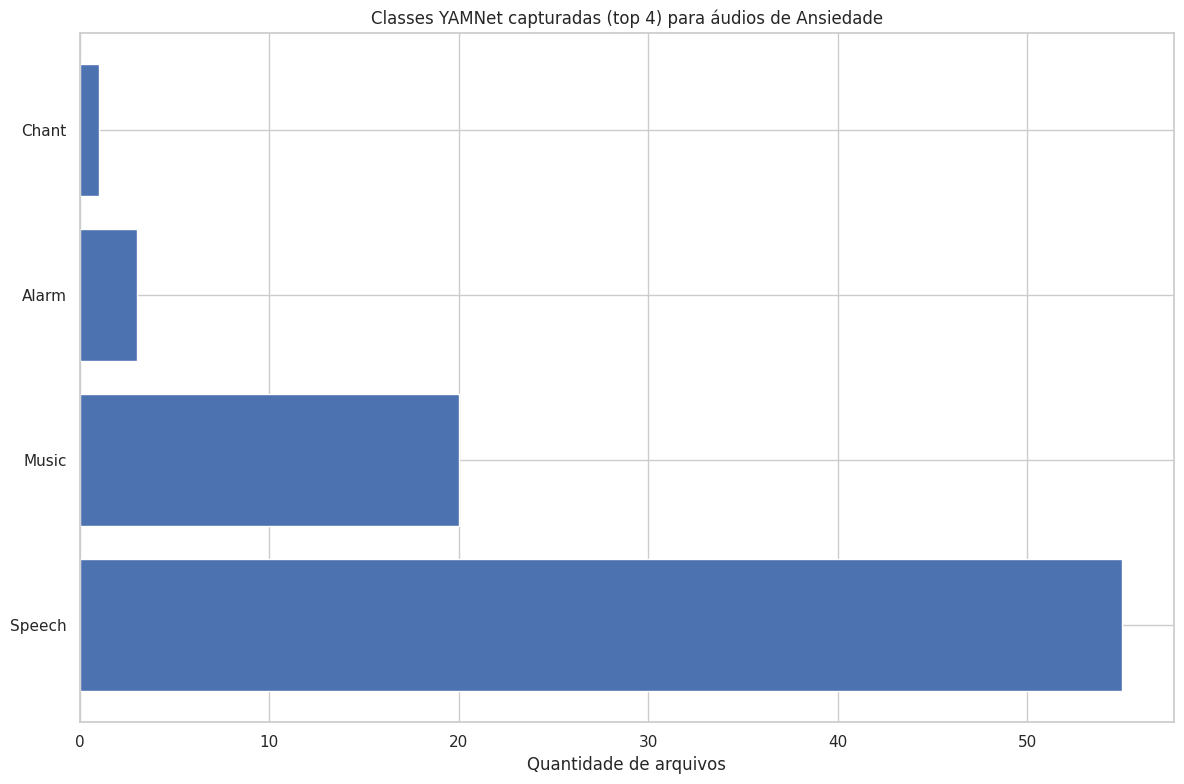

In [54]:
from collections import Counter
import matplotlib.pyplot as plt

counts = Counter(captured_classes_depression)
if not counts:
    print("Nenhuma classe capturada.")
else:
    # ordena por frequência decrescente
    labels, values = zip(*counts.most_common())

    plt.figure(figsize=(12, 8))
    plt.barh(range(len(labels))[::-1], values[::-1], color='C0')
    plt.yticks(range(len(labels))[::-1], labels[::-1])
    plt.xlabel("Quantidade de arquivos")
    plt.title(f"Classes YAMNet capturadas (top {len(labels)}) para áudios de Ansiedade")
  
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_4793/3979415309.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=values, y=labels, palette="gray")


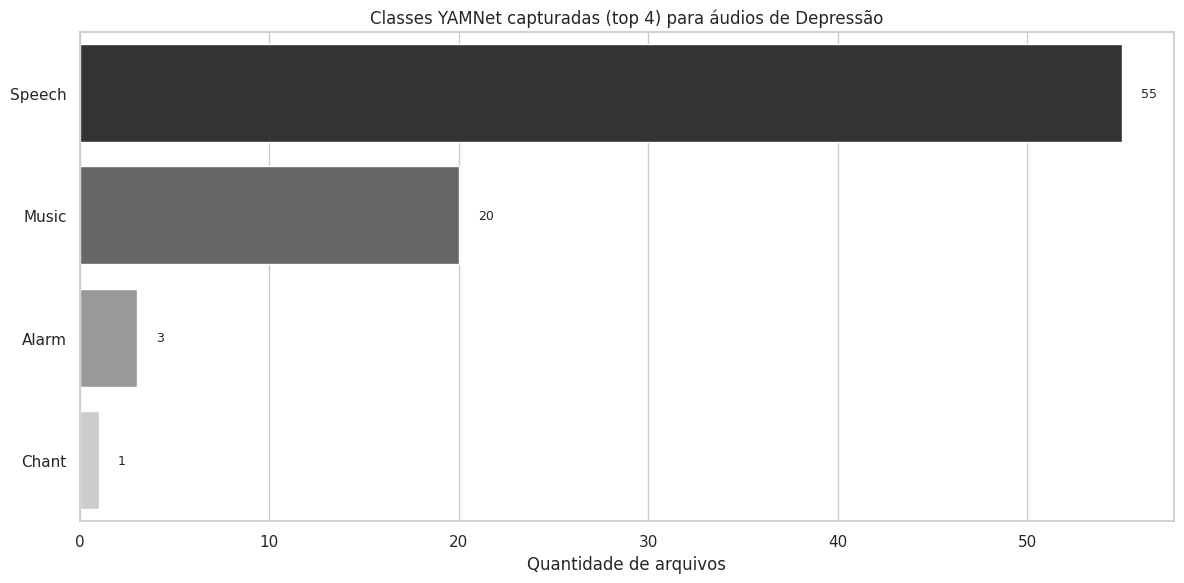

In [55]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

counts = Counter(captured_classes_depression)
if not counts:
    print("Nenhuma classe capturada.")
else:
    labels, values = zip(*counts.most_common())
    top_k = 30
    labels = list(labels)[:top_k]
    values = list(values)[:top_k]

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, max(6, 0.35 * len(labels))))
    ax = sns.barplot(x=values, y=labels, palette="gray")
    ax.set_xlabel("Quantidade de arquivos")
    ax.set_ylabel("")
    ax.set_title(f"Classes YAMNet capturadas (top {len(labels)}) para áudios de Depressão")

    x_offset = max(1, 0.01 * max(values))
    for i, v in enumerate(values):
        ax.text(v + x_offset, i, str(v), va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_4793/3476773349.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=values, y=labels, palette="gray")


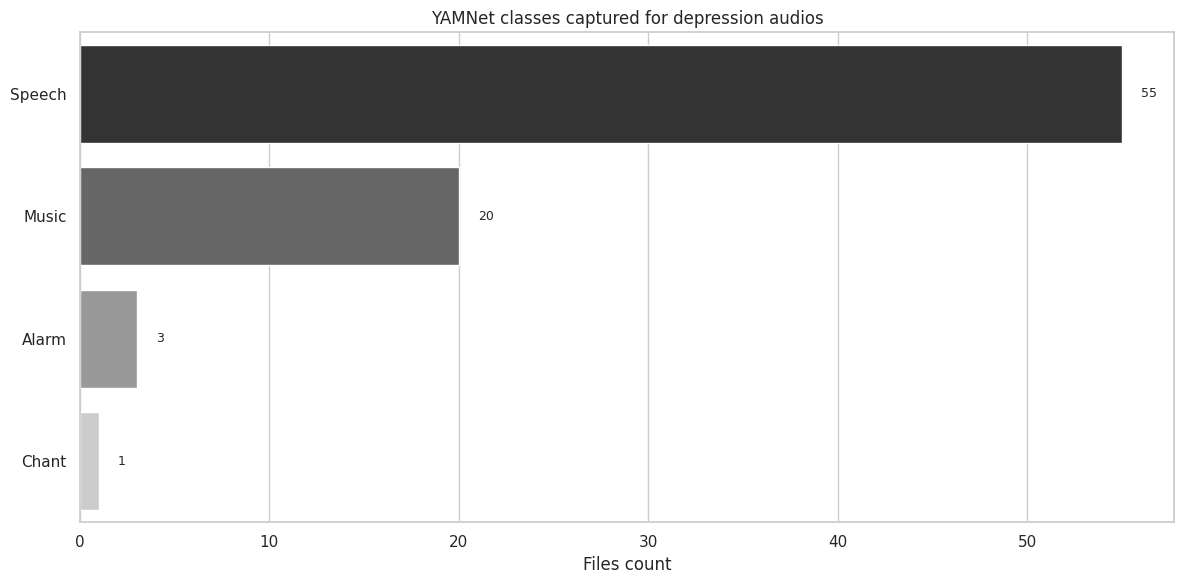

In [56]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

counts = Counter(captured_classes_depression)
if not counts:
    print("Nenhuma classe capturada.")
else:
    labels, values = zip(*counts.most_common())
    top_k = 30
    labels = list(labels)[:top_k]
    values = list(values)[:top_k]

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, max(6, 0.35 * len(labels))))
    ax = sns.barplot(x=values, y=labels, palette="gray")
    ax.set_xlabel("Files count")
    ax.set_ylabel("")
    ax.set_title("YAMNet classes captured for depression audios")

    x_offset = max(1, 0.01 * max(values))
    for i, v in enumerate(values):
        ax.text(v + x_offset, i, str(v), va="center", fontsize=9)

    plt.tight_layout()
    plt.show()